<a href="https://colab.research.google.com/github/Makkonenexe/CI345_Machine_Learning/blob/main/Homework_2_Classfication_for_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

#Mount Google Drive
diabetes_file = '/content/drive/MyDrive/CI345_ML/Data/diabetes_prediction_dataset.csv'
df = pd.read_csv(diabetes_file)
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(100000, 9)

In [ ]:
df.head(3)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0


# Step 2: Basic Data Analysis

In [ ]:
# 1) Basic Info
print("=== Basic Info ===")
df.info()

# 2) Number of rows and columns
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# 3) Column names
print("\nColumn names:", df.columns.tolist())

# 4) Data types
print("\nData types:\n", df.dtypes)

# 5) Missing data
print("\nMissing values:\n", df.isnull().sum())

# 6) Descriptive statistics of age and bmi
print("\nDescriptive statistics for Age and BMI:")
print(df[['age', 'bmi']].describe())

# 7) Mean, std, min, max
print("\nAge -> Mean:", round(df['age'].mean(),2),
      "Std:", round(df['age'].std(),2),
      "Min:", df['age'].min(),
      "Max:", df['age'].max())

print("BMI -> Mean:", round(df['bmi'].mean(),2),
      "Std:", round(df['bmi'].std(),2),
      "Min:", df['bmi'].min(),
      "Max:", df['bmi'].max())

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

Number of rows: 100000
Number of columns: 9

Column names: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Data types:
 gender                  object
age              

# Step 3: Data Visualization

<Figure size 1800x1200 with 0 Axes>

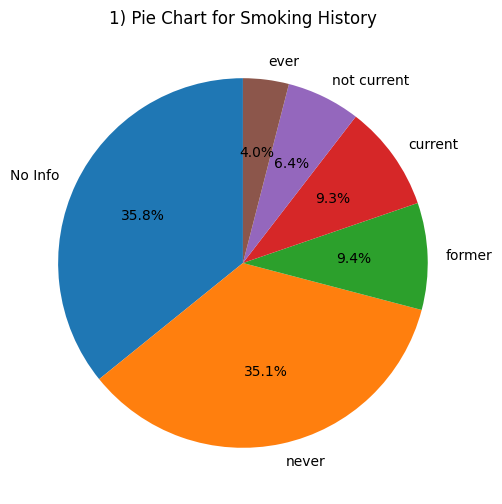

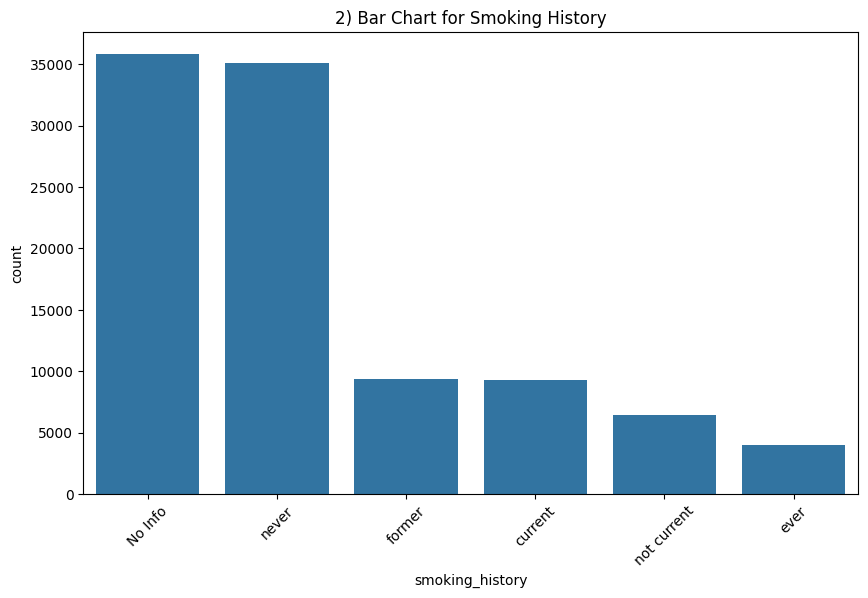

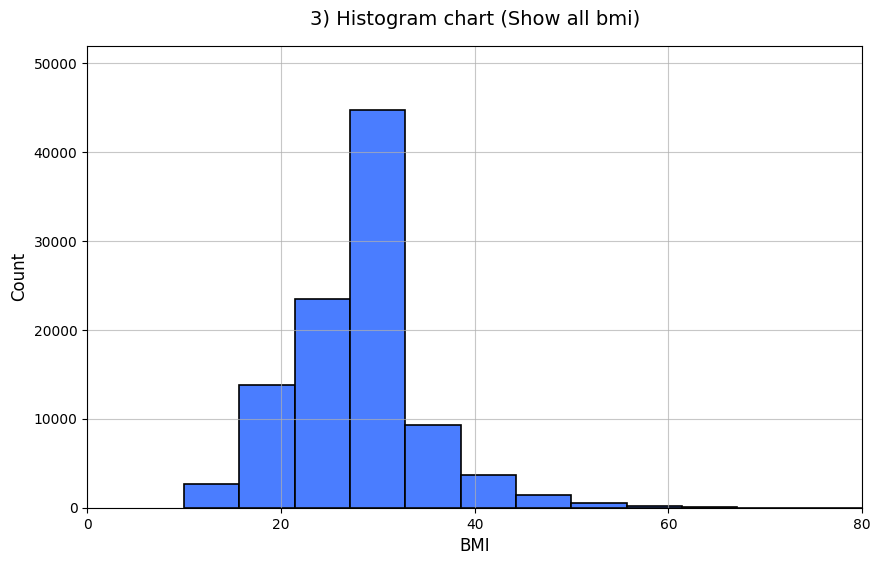

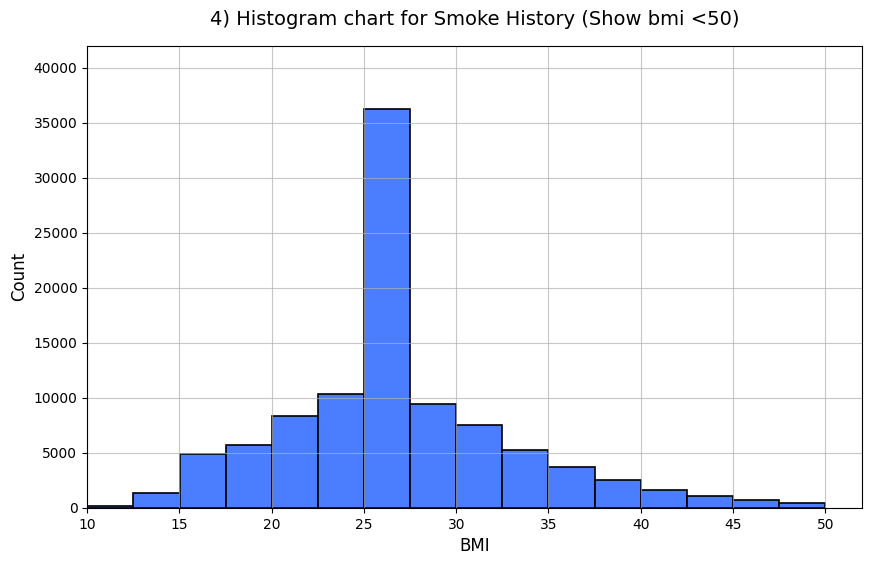

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
fig = plt.figure(figsize=(18, 12))

# 1) Pie chart for Smoke History
plt.figure(figsize=(8,6))
df['smoking_history'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('1) Pie Chart for Smoking History')
plt.ylabel('')
plt.savefig('pie_smoke_history.png')
plt.show()

# 2) Bar chart for Smoke History
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='smoking_history', order=df['smoking_history'].value_counts().index)
plt.title('2) Bar Chart for Smoking History')
plt.xticks(rotation=45)
plt.savefig('bar_smoke_history.png')
plt.show()
# 3) All BMI Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['bmi'], bins=15, color='#4a7dff', edgecolor='black', linewidth=1.2)
plt.title('3) Histogram chart (Show all bmi)', fontsize=14, pad=15)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='-', alpha=0.7)
plt.ylim(0, 52000)
plt.xlim(0, 80)
plt.xticks(range(0, 81, 20))
plt.savefig('hist_all_bmi_exact.png', dpi=400, bbox_inches='tight')

# 4) BMI <50 Histogram
plt.figure(figsize=(10, 6))
bmi_lt50 = df[df['bmi'] < 50]['bmi']
plt.hist(bmi_lt50, bins=16, color='#4a7dff', edgecolor='black', linewidth=1.2)
plt.title('4) Histogram chart for Smoke History (Show bmi <50)', fontsize=14, pad=15)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, linestyle='-', alpha=0.7)
plt.xlim(10, 52)
plt.ylim(0, 42000)
plt.xticks(range(10, 51, 5))
plt.savefig('hist_bmi_lt50_exact.png', dpi=400, bbox_inches='tight')



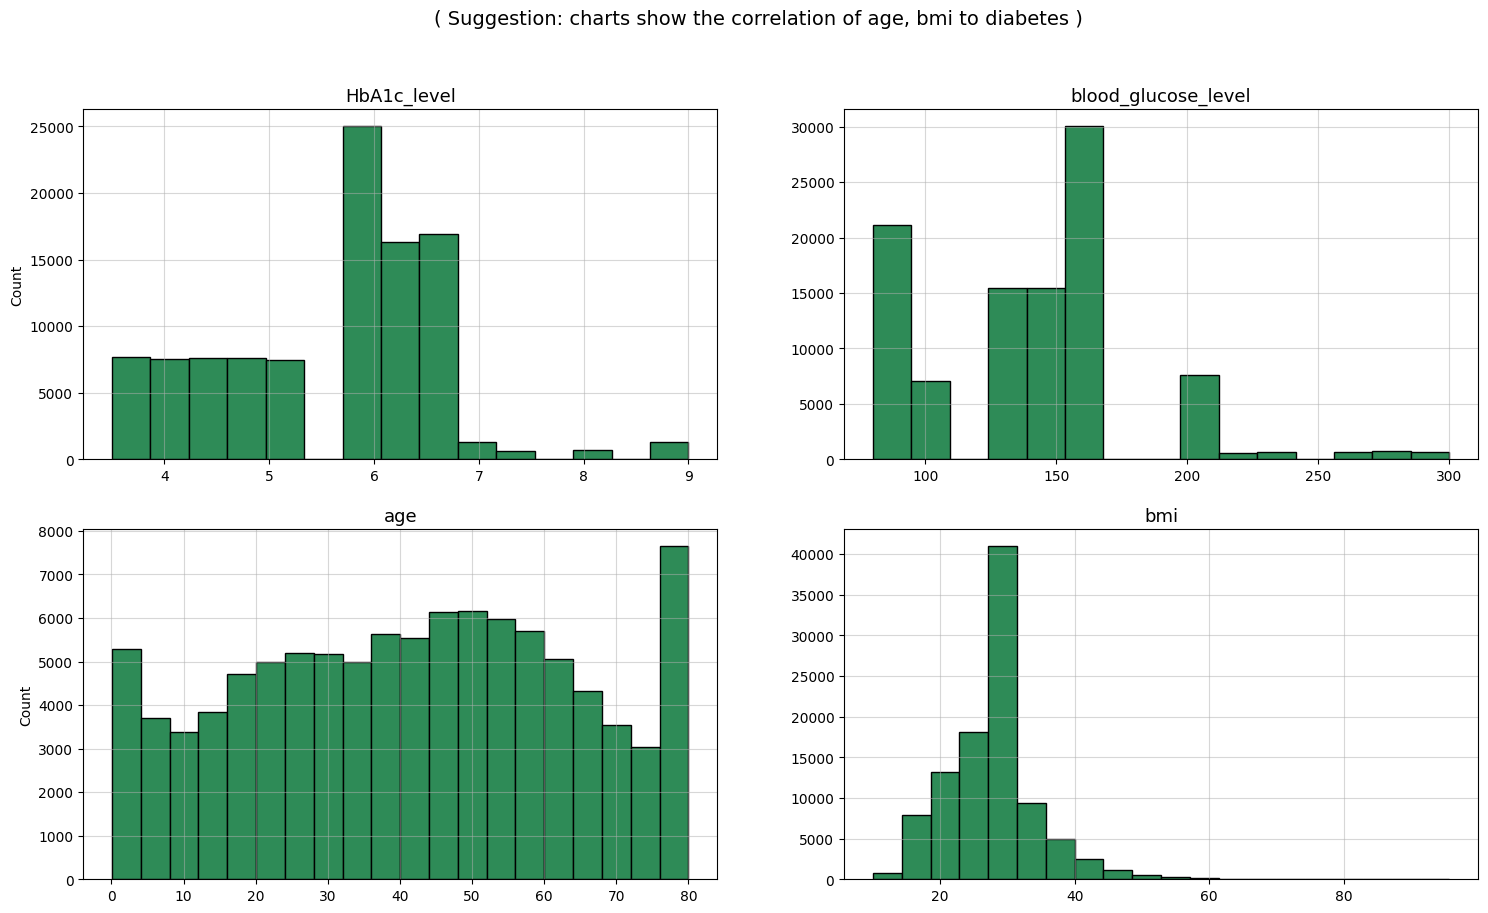


6) Target Data
diabetes
0    91500
1     8500
Name: count, dtype: int64


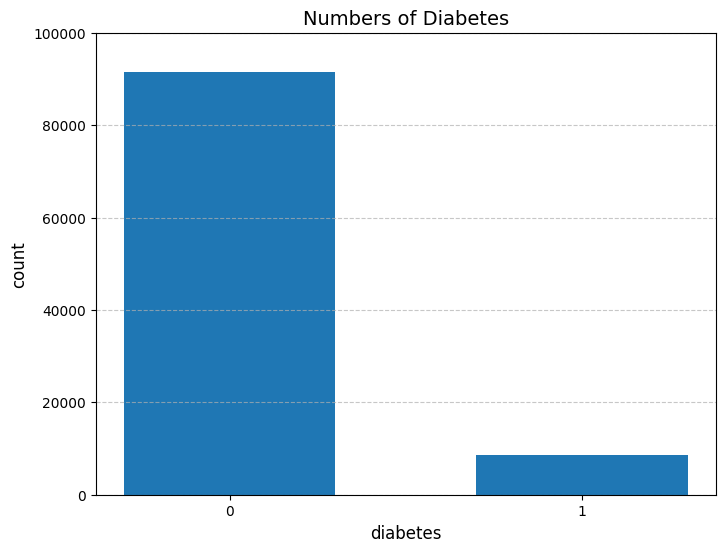

In [ ]:
# 5) charts
fig2 = plt.figure(figsize=(18, 10))
plt.subplot(2, 2, 3)
plt.hist(df['age'], bins=20, color='#2e8b57', edgecolor='black')
plt.title('age', fontsize=13)
plt.ylabel('Count')
plt.grid(True, alpha=0.5)

plt.subplot(2, 2, 4)
plt.hist(df['bmi'], bins=20, color='#2e8b57', edgecolor='black')
plt.title('bmi', fontsize=13)
plt.grid(True, alpha=0.5)


plt.subplot(2, 2, 1)
plt.hist(df['HbA1c_level'], bins=15, color='#2e8b57', edgecolor='black')
plt.title('HbA1c_level', fontsize=13)
plt.ylabel('Count')
plt.grid(True, alpha=0.5)

plt.subplot(2, 2, 2)
plt.hist(df['blood_glucose_level'], bins=15, color='#2e8b57', edgecolor='black')
plt.title('blood_glucose_level', fontsize=13)
plt.grid(True, alpha=0.5)

plt.suptitle('( Suggestion: charts show the correlation of age, bmi to diabetes )',
             fontsize=14, y=0.98)


plt.show()

# 6) Target Data
print("\n6) Target Data")

diabetes_counts = df['diabetes'].value_counts()
print(diabetes_counts)

# Create bar chart
plt.figure(figsize=(8, 6))

bars = plt.bar([0, 1], diabetes_counts.values,
               color='#1f77b4', width=0.6)

plt.title('Numbers of Diabetes', fontsize=14)
plt.xlabel('diabetes', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.xticks([0, 1], ['0', '1'])
plt.ylim(0, 100000)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

# Step 4: Data Processing

In [64]:
# Only converting categoric features to numerical feature
# Method 3 : Using get_dummies -
category_cols = ['gender','smoking_history']

df_use_dummies = pd.get_dummies(df, columns = category_cols , dtype=int )
print('----------')
print(df_use_dummies.dtypes)
df_use_dummies.head(2)

----------
age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level              int64
diabetes                         int64
gender_encoded                   int64
smoking_hist                     int64
gender_Female                    int64
gender_Male                      int64
gender_Other                     int64
smoking_history_No Info          int64
smoking_history_current          int64
smoking_history_ever             int64
smoking_history_former           int64
smoking_history_never            int64
smoking_history_not current      int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_encoded,smoking_hist,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,2,1,0,0,1,0,0,0,0,0


# Step 5: Separate Features and Target

In [65]:
print(df.columns)
cols_used = ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_hist',
'HbA1c_level', 'blood_glucose_level']

# Separate data part
data = df[cols_used]
# Get target
target = df['diabetes']

print(data.shape)
print(target.shape)
print(target.head(2) )
data.head(3)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes',
       'gender_encoded', 'smoking_hist'],
      dtype='object')
(100000, 7)
(100000,)
0    0
1    0
Name: diabetes, dtype: int64


,gender,age,hypertension,heart_disease,smoking_hist,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,0,6.6,140
1,Female,54.0,0,0,2,6.6,80
2,Male,28.0,0,0,0,5.7,158


# Step 6: Training Three Classifiers

In [58]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split completed - Training samples:", len(X_train))

# 1) KNN Classifier
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    print(f"\nKNN (k={k}) Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 2) Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# 3) SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("\nSVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Data split completed - Training samples: 80000

KNN (k=3) Accuracy: 0.9523
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     18300
           1       0.81      0.57      0.67      1700

    accuracy                           0.95     20000
   macro avg       0.89      0.78      0.82     20000
weighted avg       0.95      0.95      0.95     20000

Confusion Matrix:
 [[18080   220]
 [  734   966]]

KNN (k=5) Accuracy: 0.9552
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     18300
           1       0.88      0.55      0.67      1700

    accuracy                           0.96     20000
   macro avg       0.92      0.77      0.83     20000
weighted avg       0.95      0.96      0.95     20000

Confusion Matrix:
 [[18173   127]
 [  770   930]]

KNN (k=7) Accuracy: 0.9552
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18300
      

# Step 7: Finishing the Table

In [73]:
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def get_metrics(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    return [tp, fp, tn, fn, round(precision, 3), round(recall, 3), round(accuracy, 3)]

data = [
    ["KNN", *get_metrics(KNeighborsClassifier(n_neighbors=3))],
    ["KNN", *get_metrics(KNeighborsClassifier(n_neighbors=5))],
    ["KNN", *get_metrics(KNeighborsClassifier(n_neighbors=7))],
    ["Decision Tree", *get_metrics(DecisionTreeClassifier(random_state=42, max_depth=5))],
    ["SVM", *get_metrics(SVC(kernel='rbf', random_state=42))]
]

columns = ['Classifier', 'TP', 'FP', 'TN', 'FN', 'Precision', 'Recall', 'Accuracy']
result_table = pd.DataFrame(data, columns=columns)
result_table


,Classifier,TP,FP,TN,FN,Precision,Recall,Accuracy
0,KNN,40,27,124,40,0.597,0.500,0.710
1,KNN,43,32,119,37,0.573,0.537,0.701
2,KNN,40,30,121,40,0.571,0.500,0.697
3,Decision Tree,44,22,129,36,0.667,0.550,0.749
4,SVM,47,26,125,33,0.644,0.588,0.745
